In [11]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation across all genes

In [24]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

# If expression prediction, then keep false
abs_phenotypes = False

config_path = "/home/dnanexus/ukbgym/config_olink.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#1f77b4""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",1
…,…,…,…,…
"""splicing""","""absplice2_max""","""#1E8449""","""AbSplice2 (max)""",-1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1
"""regulatory_nondir""","""abexp_min""","""#00A99D""","""AbExp min""",1


In [13]:
# abs_phenotypes = False
# anno_config_df = anno_config_df.filter(pl.col('category').is_in(['regulatory']))


# anno_config_df = anno_config_df.filter(~pl.col('category').is_in(['regulatory']))
# all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
# anno_config_df

In [14]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_250928.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# Filter variant classes
min_range = -100
max_range = +0

variant_class = "missense"
abs_phenotypes = False

consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

anno_wide = (
    anno
    .filter(
        filter_expression &
        # (pl.col('consequence_splice_acceptor_variant') == 0) & (pl.col('consequence_splice_donor_variant') == 0) &
        # ((pl.col('consequence_splice_acceptor_variant') == 1) | (pl.col('consequence_splice_donor_variant') == 1)) &
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

absplice_dna_max,abexp_min,gpn_score,am_pathogenicity,gene_name,loftee_hc,region,TSS,esmscoremissense,promoterai,absplice2_max,pangolin_score,gpn_star_llr_calibrated_mean,cadd_raw,promoterai_abs,verphylop,mamphylop,id,gene_length,dist_to_tss,delta_score,Strand
f32,f64,f32,f32,str,i8,str,i64,f32,f32,f32,f32,f64,f32,f32,f32,f32,str,i64,i64,f32,cat
0.003,-0.053713,-3.57,0.0607,"""ABCB11""",0,"""ENSG00000073734""",169031324,-2.337,0.0,0.000095,0.0,-2.904763,1.464585,0.0,0.637,1.883,"""chr2:168969544:T:C""",115828,61780,0.0,"""-"""
0.002861,-0.123061,-10.59,0.9928,"""SCN2A""",0,"""ENSG00000136531""",165194992,-8.912,0.0,0.00032,0.0,-10.240548,4.659599,0.0,11.295,4.494,"""chr2:165386841:G:T""",197319,191849,0.0,"""+"""
0.001,-0.019552,-4.21,0.0739,"""ABCB11""",0,"""ENSG00000073734""",169031324,-3.64,0.0,0.00006,0.0,-3.660376,0.654511,0.0,0.234,-0.435,"""chr2:169014334:C:G""",115828,16990,0.21,"""-"""
0.003,-0.080146,-7.05,0.61,"""ABCB11""",0,"""ENSG00000073734""",169031324,-11.82,0.0,0.000308,0.0,-7.286326,5.473324,0.0,11.295,4.494,"""chr2:168923755:G:A""",115828,107569,0.0,"""-"""
0.003,-0.079081,-4.13,0.0997,"""LRP2""",0,"""ENSG00000081479""",169362534,-3.115,0.0,0.000314,0.03,-5.218755,2.173019,0.0,2.741,1.179,"""chr2:169173984:T:C""",235427,188550,0.05,"""-"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,null,-6.52,0.0,"""CNTN3""",0,"""ENSG00000113805""",74614659,0.0,0.0,0.0,0.0,-4.59337,2.659422,0.0,2.139,1.612,"""chr3:74577406:T:G""",352093,37253,0.0,"""-"""
0.0,null,-0.23,0.0,"""ABTB1""",0,"""ENSG00000114626""",127672934,0.0,0.0,0.0,0.0,0.395675,0.809665,0.0,-1.127,-1.198,"""chr3:127683339:A:G""",7993,10405,0.0,"""+"""
0.0,null,-1.04,0.0,"""CNTN3""",0,"""ENSG00000113805""",74614659,0.0,0.0,0.0,0.0,-0.44362,0.178626,0.0,-0.752,-0.502,"""chr3:74544344:T:C""",352093,70315,0.0,"""-"""


In [15]:
# new_anno = pl.scan_parquet("/home/dnanexus/data_dir/abexp1.1_annotations_all_ukb_vars_genebass1e6.parquet")
# # new_anno.head().collect()
# new_anno = new_anno.select(['id', 'region', 'abexp_whole_blood']).collect()
# new_anno = new_anno.filter(pl.col('abexp_whole_blood').is_not_null())

# anno_wide = anno_wide.join(new_anno, on=['id', 'region'], how='left').filter(pl.col('abexp_whole_blood').is_not_null())

# existing_annos += ['abexp_whole_blood']

# anno_wide

In [16]:
melted_anno = anno_wide.unpivot(
    index=["id", "region", "gene_name"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,gene_name,annotation,annotation_score
str,str,str,str,f32
"""chr2:168969544:T:C""","""ENSG00000073734""","""ABCB11""","""loftee_hc""",0.0
"""chr2:165386841:G:T""","""ENSG00000136531""","""SCN2A""","""loftee_hc""",0.0
"""chr2:169014334:C:G""","""ENSG00000073734""","""ABCB11""","""loftee_hc""",0.0
"""chr2:168923755:G:A""","""ENSG00000073734""","""ABCB11""","""loftee_hc""",0.0
"""chr2:169173984:T:C""","""ENSG00000081479""","""LRP2""","""loftee_hc""",0.0
…,…,…,…,…
"""chr3:74577406:T:G""","""ENSG00000113805""","""CNTN3""","""abexp_min""",null
"""chr3:127683339:A:G""","""ENSG00000114626""","""ABTB1""","""abexp_min""",null
"""chr3:74544344:T:C""","""ENSG00000113805""","""CNTN3""","""abexp_min""",null


In [17]:
# --- 1. Lazily prepare the filter keys ---

# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "gene_name", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['mean_pheno_value', 'annotation_score']
    )
    .group_by(["region", "gene_name", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
    )
    .rename({
        'phenotype': 'olink_prot',
    })
    .collect(engine='streaming')
)

gp_corr_df

region,gene_name,olink_prot,annotation,n_variants,correlation
str,str,str,str,u64,f64
"""ENSG00000136542""","""GALNT5""","""ENSG00000136542_olink""","""absplice_dna_max""",136,-0.247053
"""ENSG00000127324""","""TSPAN8""","""ENSG00000127324_olink""","""gpn_star_llr_calibrated_mean""",22,-0.189159
"""ENSG00000264522""","""OTUD7B""","""ENSG00000264522_olink""","""promoterai""",111,NaN
"""ENSG00000168758""","""SEMA4C""","""ENSG00000168758_olink""","""loftee_hc""",142,NaN
"""ENSG00000213398""","""LCAT""","""ENSG00000213398_olink""","""esmscoremissense""",70,0.476939
…,…,…,…,…,…
"""ENSG00000198670""","""LPA""","""ENSG00000198670_olink""","""gpn_score""",267,0.031453
"""ENSG00000125977""","""EIF2S2""","""ENSG00000125977_olink""","""absplice2_max""",18,-0.217375
"""ENSG00000125977""","""EIF2S2""","""ENSG00000125977_olink""","""mamphylop""",18,0.12552


In [25]:
gp_corr_df = (
    gp_corr_df
    .select(['region', 'gene_name', 'olink_prot', 'annotation', 'n_variants', 'correlation'])
    .join(
        anno_config_df,
        on='annotation'
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('annotation_dir')
    )
)
gp_corr_df#['annotation'].value_counts(sort=True)

region,gene_name,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta
str,str,str,str,u64,f64,str,str,str,i64,f64
"""ENSG00000136542""","""GALNT5""","""ENSG00000136542_olink""","""absplice_dna_max""",136,-0.247053,"""splicing""","""#28a745""","""AbSplice (max)""",-1,0.247053
"""ENSG00000127324""","""TSPAN8""","""ENSG00000127324_olink""","""gpn_star_llr_calibrated_mean""",22,-0.189159,"""conservation""","""#942c80""","""GPN-Star""",1,-0.189159
"""ENSG00000264522""","""OTUD7B""","""ENSG00000264522_olink""","""promoterai""",111,NaN,"""regulatory""","""#00A99D""","""PromoterAI""",1,NaN
"""ENSG00000168758""","""SEMA4C""","""ENSG00000168758_olink""","""loftee_hc""",142,NaN,"""plof""","""#1f77b4""","""LOFTEE HC""",-1,NaN
"""ENSG00000213398""","""LCAT""","""ENSG00000213398_olink""","""esmscoremissense""",70,0.476939,"""missense""","""#feb72d""","""ESM1v""",1,0.476939
…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000004939""","""SLC4A1""","""ENSG00000004939_olink""","""gpn_star_llr_calibrated_mean""",152,0.025776,"""conservation""","""#942c80""","""GPN-Star""",1,0.025776
"""ENSG00000178568""","""ERBB4""","""ENSG00000178568_olink""","""abexp_min""",364,0.075301,"""regulatory_nondir""","""#00A99D""","""AbExp min""",1,0.075301
"""ENSG00000178568""","""ERBB4""","""ENSG00000178568_olink""","""abexp_min""",364,0.075301,"""regulatory""","""#00A99D""","""AbExp min""",1,0.075301


In [33]:
# filt_corr_df = gp_corr_df.filter(~pl.col('category').is_in(['naive']))
filt_corr_df = gp_corr_df.filter(pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']))
# filt_corr_df = gp_corr_df.filter(pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']))

consistent_genes = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'gene_name'])
    .agg(n_annotations = pl.len())
    .sort('n_annotations', descending=True)
    .filter(pl.col('n_annotations') == filt_corr_df['annotation'].n_unique())
)

filt_corr_df = filt_corr_df.join(consistent_genes, on=['region', 'gene_name'], how='inner')
# filt_corr_df = filt_corr_df.filter(pl.col("n_variants") > 10)  # Filter for groups with more than 10 variants
filt_corr_df = filt_corr_df.filter(pl.col("n_variants") > 100)
filt_corr_df.sort('corr_beta', descending=True)

region,gene_name,olink_prot,annotation,n_variants,correlation,category,color,label,annotation_dir,corr_beta,n_annotations
str,str,str,str,u64,f64,str,str,str,i64,f64,u64
"""ENSG00000133805""","""AMPD3""","""ENSG00000133805_olink""","""am_pathogenicity""",134,-0.665097,"""missense""","""#feb72d""","""AlphaMissense""",-1,0.665097,7
"""ENSG00000078098""","""FAP""","""ENSG00000078098_olink""","""esmscoremissense""",117,0.603353,"""missense""","""#feb72d""","""ESM1v""",1,0.603353,7
"""ENSG00000197635""","""DPP4""","""ENSG00000197635_olink""","""gpn_star_llr_calibrated_mean""",120,0.596654,"""conservation""","""#942c80""","""GPN-Star""",1,0.596654,7
"""ENSG00000133805""","""AMPD3""","""ENSG00000133805_olink""","""esmscoremissense""",134,0.595722,"""missense""","""#feb72d""","""ESM1v""",1,0.595722,7
"""ENSG00000197635""","""DPP4""","""ENSG00000197635_olink""","""gpn_score""",120,0.579476,"""conservation""","""#942c80""","""GPN-MSA""",1,0.579476,7
…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000102755""","""FLT1""","""ENSG00000102755_olink""","""verphylop""",169,0.183053,"""conservation""","""#942c80""","""Vertebrate PhyloP""",-1,-0.183053,7
"""ENSG00000106991""","""ENG""","""ENSG00000106991_olink""","""mamphylop""",117,0.193472,"""conservation""","""#942c80""","""Mammalian PhyloP""",-1,-0.193472,7
"""ENSG00000066468""","""FGFR2""","""ENSG00000066468_olink""","""gpn_star_llr_calibrated_mean""",102,-0.193807,"""conservation""","""#942c80""","""GPN-Star""",1,-0.193807,7


In [34]:
# Filter to only those with sign agreement
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'gene_name', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


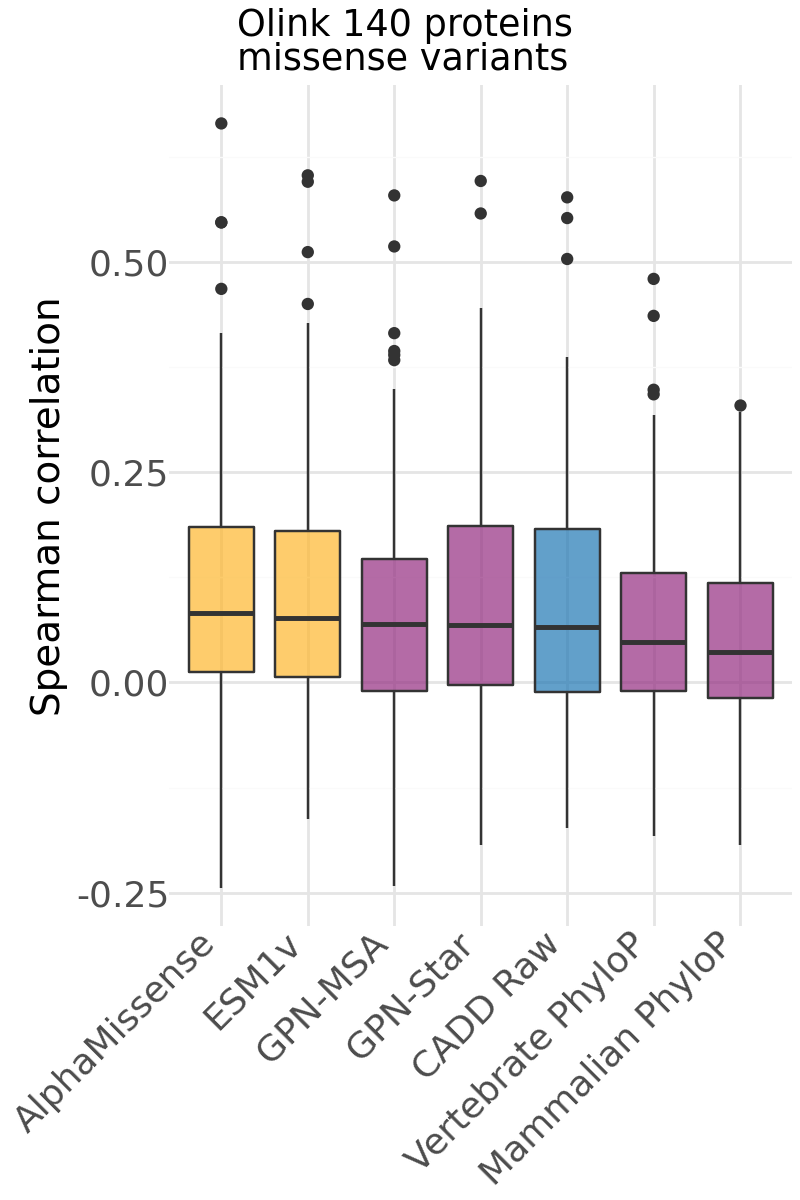

In [35]:
med_df = filt_corr_df.drop_nans().group_by("annotation").agg([
    pl.col("corr_beta").median().alias("median_abs_corr"),
])

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_abs_corr', ascending=False)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y="corr_beta", fill="annotation")) +
    geom_boxplot(alpha=0.7) +
    theme_minimal() +
    scale_fill_manual(values=color_dict) +
    # lims(
    #     y=(-0.1, 0.3)
    # ) +
    labs(
        x="",
        y="Spearman correlation",
        title=f"Olink {len(corr_pd['region'].unique())} proteins \
            \n{variant_class} variants"
            # \nTSS [{min_range}bp, {max_range}bp]"
            # \nGene body ±10kb"
            # \nsplice donor/acceptor variants"
    ) +
    theme(
        figure_size=(4, 6),
        legend_position="none",
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=13),
        axis_title=element_text(size=14),
        legend_text=element_text(size=13),
        legend_title=element_text(size=14),
    )
)

In [36]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "corr_beta"])

    merged = df_a.join(df_b, on=["region"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_68074/863415217.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""cadd_raw""","""mamphylop""",140,2007.0,1.1259e-9
"""gpn_star_llr_calibrated_mean""","""mamphylop""",140,2205.0,1.3580e-8
"""am_pathogenicity""","""mamphylop""",140,2339.0,6.6688e-8
"""esmscoremissense""","""mamphylop""",140,2368.0,9.3177e-8
"""verphylop""","""cadd_raw""",140,2549.0,6.9392e-7
…,…,…,…,…
"""gpn_star_llr_calibrated_mean""","""gpn_score""",140,3306.0,0.000703
"""esmscoremissense""","""gpn_score""",140,3451.0,0.002023
"""verphylop""","""mamphylop""",140,3535.0,0.00359


# Correlation across all genes

In [85]:
# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

appv = (
    olink_appv
    .rename({
        'phenotype': 'olink_prot',
        'mean_pheno_value': 'mean_olink_value',
        'std_pheno_value': 'std_olink_value',
    })
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_olink_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_olink_value').abs())
        .otherwise(pl.col('mean_olink_value'))
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('olink_prot')
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).lazy(), 
        on=['id', 'region'],
        how='inner'
    )
    .collect(engine='streaming')
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,olink_prot,n_individuals,mean_olink_value,std_olink_value,region,gene_name,annotation,annotation_score,TSS,Strand,gene_length,gene_name_right,dist_to_tss
str,str,u64,f32,f32,str,str,str,f32,i64,cat,i64,str,i64
"""chr6:26459772:G:T""","""ENSG00000112763_olink""",3,-2.625185,0.162608,"""ENSG00000112763""","""BTN2A1""","""loftee_hc""",0.0,26457903,"""+""",18719,"""BTN2A1""",1869
"""chr2:211598916:G:A""","""ENSG00000178568_olink""",2,-0.269417,0.576509,"""ENSG00000178568""","""ERBB4""","""loftee_hc""",0.0,212538841,"""-""",1163126,"""ERBB4""",939925
"""chr2:21025906:C:T""","""ENSG00000084674_olink""",1,-0.715945,null,"""ENSG00000084674""","""APOB""","""loftee_hc""",0.0,21044073,"""-""",42646,"""APOB""",18167
"""chr2:211448013:C:A""","""ENSG00000178568_olink""",2,-0.342948,0.587571,"""ENSG00000178568""","""ERBB4""","""loftee_hc""",0.0,212538841,"""-""",1163126,"""ERBB4""",1090828
"""chr2:209446666:C:T""","""ENSG00000078018_olink""",1,1.08682,null,"""ENSG00000078018""","""MAP2""","""loftee_hc""",0.0,209424046,"""+""",310073,"""MAP2""",22620
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr17:64131886:C:G""","""ENSG00000178607_olink""",1,0.727674,null,"""ENSG00000178607""","""ERN1""","""abexp_min""",null,64130819,"""-""",91741,"""ERN1""",-1067
"""chr19:42563000:C:T""","""ENSG00000079385_olink""",12,0.037813,1.004856,"""ENSG00000079385""","""CEACAM1""","""abexp_min""",null,42561234,"""-""",53932,"""CEACAM1""",-1766
"""chr2:213154721:A:G""","""ENSG00000030419_olink""",1,1.517808,null,"""ENSG00000030419""","""IKZF2""","""abexp_min""",null,213152427,"""-""",152738,"""IKZF2""",-2294


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 321050 rows containing missing values.


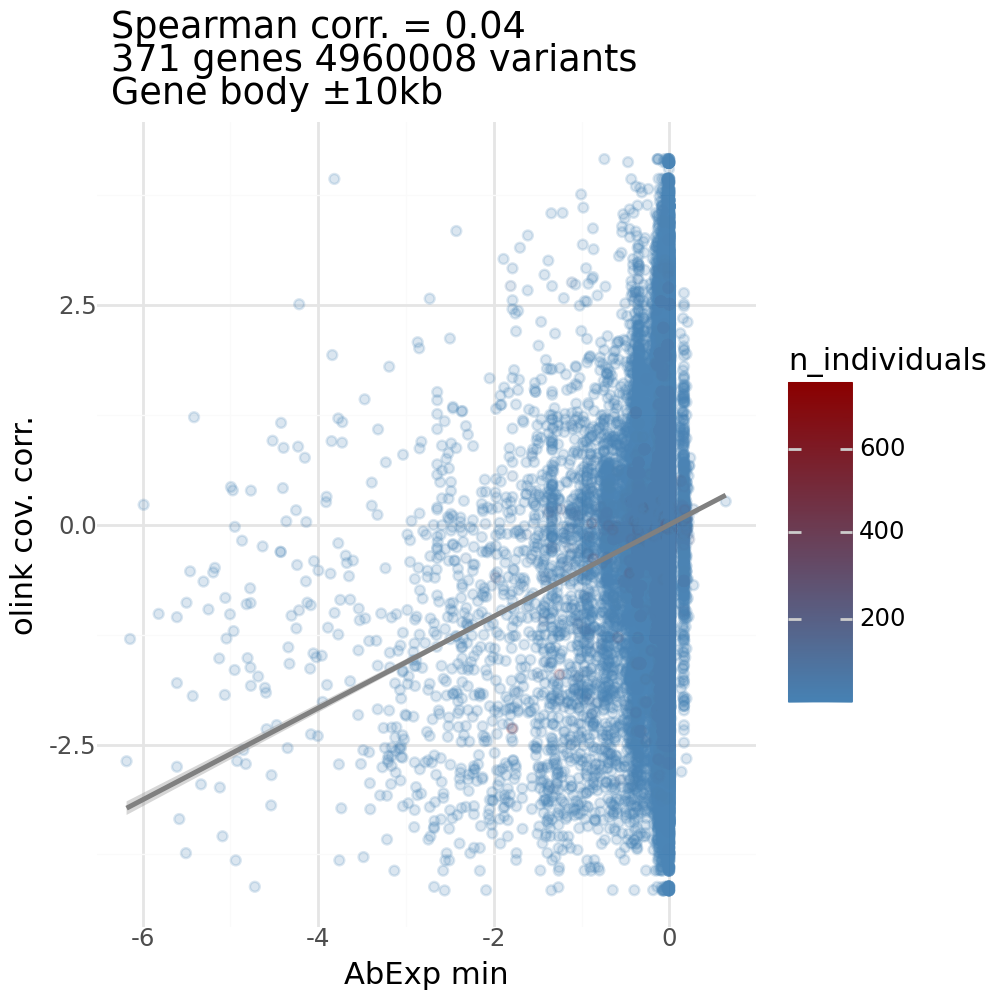

In [88]:
annotation = 'promoterai'
# annotation = 'gpn_star_llr_calibrated_mean'
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('gene_name') == gene_name) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_olink_value', color='n_individuals')) +
    geom_point(alpha=0.1) +
    geom_smooth(method='glm', se=True, color='gray') +
    scale_color_gradient(low='steelblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"olink cov. corr.",
        title=f"Spearman corr. = {plot_df.select(pl.corr('annotation_score', 'mean_olink_value')).to_series()[0]:.2f} \
        \n{pg_df['gene_name'].n_unique()} genes {plot_df.shape[0]} variants \
        \nGene body ±10kb"
        # \n[{min_range}bp, {max_range}bp]"
    ) +
    theme(figure_size=(5, 5))
)